# Does 365-day history add predictive signal?

The previous baseline used only the immediately previous inspection. Here I test whether adding the establishment's recent 365-day inspection history improves prediction, using the same model, same target, and the same evaluation setup so the comparison is fair.

One correction from the previous notebook: that split was 70/15/15 by row count after sorting by date, which let a few rows on the same boundary date land in two different splits. Here the split is strict by date, so no calendar date appears in more than one split. Because of that, the baseline (previous-inspection-only) model is also rerun under this stricter split, so the comparison is apples to apples and not confounded by the split fix.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score, precision_score,
                              recall_score, f1_score, accuracy_score, confusion_matrix,
                              precision_recall_curve, roc_curve)

df = pd.read_csv("../outputs/prediction_events_current_v1.csv",
                  parse_dates=["inspectionDate", "prev_inspectionDate"], low_memory=False)
print("rows:", len(df))
assert len(df) == 69766

rows: 69766


## Feature sets

Same 7 previous-inspection features as before, plus the 4 simple 365-day history features already present in the dataset.

In [2]:
BASE_FEATURES = ["days_since_previous_inspection", "prev_non_pass", "prev_total_infractions",
                  "prev_minor", "prev_significant", "prev_crucial", "n_inspections_seen_so_far"]

HIST_COLS = ["prior_365d_n_inspections", "prior_365d_n_non_pass",
             "prior_365d_total_infractions", "prior_365d_crucial_infractions"]

HIST_FEATURES = BASE_FEATURES + HIST_COLS

# check the 365-day columns already exist and look sane, no need to recompute them
for c in HIST_COLS:
    print(c, df[c].dtype, "min", df[c].min(), "max", df[c].max(), "na", df[c].isna().sum())

identifier_cols = {"estId", "oldEstId", "_id", "unique_id"}
outcome_cols = {"OutcomeDate", "OutcomeDesc", "amountFined", "inspectionStatus"}
assert identifier_cols.isdisjoint(HIST_FEATURES)
assert outcome_cols.isdisjoint(HIST_FEATURES)
assert "latitude" not in HIST_FEATURES and "longitude" not in HIST_FEATURES

prior_365d_n_inspections int64 min 0 max 9 na 0
prior_365d_n_non_pass int64 min 0 max 6 na 0
prior_365d_total_infractions int64 min 0 max 50 na 0
prior_365d_crucial_infractions int64 min 0 max 10 na 0


## Strict date-based train / validation / test split

Sorted by target date, split on unique dates (not rows) at roughly the 70th and 85th percentile of the date range, so every row on a given date goes to exactly one split. Row counts across splits won't be exactly 70/15/15 as a result, that's expected and fine, strict chronology matters more here.

The same establishment can still show up in more than one split, since its earlier inspections legitimately belong in training and its later ones in validation or test. That's the intended setup for a future-prediction task, not group leakage. What matters is that no target date is used out of order.

In [3]:
df = df.sort_values("inspectionDate").reset_index(drop=True)

unique_dates = np.sort(df["inspectionDate"].unique())
n_dates = len(unique_dates)
train_cut = unique_dates[int(n_dates * 0.70)]
val_cut = unique_dates[int(n_dates * 0.85)]

train = df[df["inspectionDate"] < train_cut].copy()
val = df[(df["inspectionDate"] >= train_cut) & (df["inspectionDate"] < val_cut)].copy()
test = df[df["inspectionDate"] >= val_cut].copy()

for name, part in [("train", train), ("val", val), ("test", test)]:
    print(f"{name}: rows={len(part)} establishments={part['estId'].nunique()} "
          f"{part['inspectionDate'].min().date()} to {part['inspectionDate'].max().date()} "
          f"non-pass%={round(100*part['target'].mean(),3)}")

train: rows=45334 establishments=14557 2023-11-10 to 2025-11-05 non-pass%=5.548
val: rows=11740 establishments=9309 2025-11-06 to 2026-04-09 non-pass%=6.422
test: rows=12692 establishments=10361 2026-04-10 to 2026-09-08 non-pass%=7.517


In [4]:
assert train["inspectionDate"].max() < val["inspectionDate"].min()
assert val["inspectionDate"].max() < test["inspectionDate"].min()
print("strict temporal ordering confirmed")

strict temporal ordering confirmed


## Leakage checks

In [5]:
assert (df["inspectionDate"] > df["prev_inspectionDate"]).all()
assert (train["inspectionDate"] < pd.Timestamp("2023-11-10")).sum() == 0  # sanity, all current-period
assert df["inspectionDate"].min() >= pd.Timestamp("2023-11-10")
assert not df.duplicated(subset=["estId", "inspectionDate"]).any()
assert identifier_cols.isdisjoint(HIST_FEATURES)
assert outcome_cols.isdisjoint(HIST_FEATURES)
# 365-day features are built from inspections strictly before the target date (see notebook 03),
# already verified there with a brute-force spot check, not repeated here
print("leakage checks passed")

leakage checks passed


## Train and evaluate a model

Same pipeline and model as the baseline notebook: median imputation, standard scaling, `LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)`. One function so the baseline and history model are trained and evaluated identically.

In [6]:
def run_model(features, label):
    X_train, y_train = train[features], train["target"]
    X_val, y_val = val[features], val["target"]
    X_test, y_test = test[features], test["target"]

    pipe = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
    ])
    pipe.fit(X_train, y_train)

    val_proba = pipe.predict_proba(X_val)[:, 1]
    val_pr_auc = average_precision_score(y_val, val_proba)
    val_roc_auc = roc_auc_score(y_val, val_proba)

    thresh_rows = []
    for t in [0.30, 0.40, 0.50, 0.60, 0.70]:
        pred = (val_proba >= t).astype(int)
        thresh_rows.append({"threshold": t, "f1": f1_score(y_val, pred, zero_division=0)})
    thresh_df = pd.DataFrame(thresh_rows)
    best_t = thresh_df.loc[thresh_df["f1"].idxmax(), "threshold"]

    test_proba = pipe.predict_proba(X_test)[:, 1]
    test_pred = (test_proba >= best_t).astype(int)

    metrics = {
        "label": label,
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": val_roc_auc,
        "threshold": best_t,
        "test_pr_auc": average_precision_score(y_test, test_proba),
        "test_roc_auc": roc_auc_score(y_test, test_proba),
        "test_precision": precision_score(y_test, test_pred, zero_division=0),
        "test_recall": recall_score(y_test, test_pred, zero_division=0),
        "test_f1": f1_score(y_test, test_pred, zero_division=0),
        "test_accuracy": accuracy_score(y_test, test_pred),
    }
    cm = confusion_matrix(y_test, test_pred)
    return pipe, metrics, cm, test_proba

## Baseline, rerun under the strict split (previous-inspection features only)

In [7]:
pipe_base, metrics_base, cm_base, proba_base = run_model(BASE_FEATURES, "baseline_strict_split")
print(metrics_base)
print("confusion matrix:\n", cm_base)

{'label': 'baseline_strict_split', 'val_pr_auc': 0.11097619081986218, 'val_roc_auc': 0.636980101513332, 'threshold': np.float64(0.6), 'test_pr_auc': 0.12741365121729256, 'test_roc_auc': 0.6440100921124496, 'test_precision': 0.1505524861878453, 'test_recall': 0.22851153039832284, 'test_f1': 0.18151540383014156, 'test_accuracy': 0.8450992751339427}
confusion matrix:
 [[10508  1230]
 [  736   218]]


## History model (previous inspection + 365-day history)

In [8]:
pipe_hist, metrics_hist, cm_hist, proba_hist = run_model(HIST_FEATURES, "history_365d")
print(metrics_hist)
print("confusion matrix:\n", cm_hist)

{'label': 'history_365d', 'val_pr_auc': 0.16006351798195775, 'val_roc_auc': 0.7220246192284272, 'threshold': np.float64(0.6), 'test_pr_auc': 0.16238814021022, 'test_roc_auc': 0.704138853793499, 'test_precision': 0.1868377021751255, 'test_recall': 0.35115303983228513, 'test_f1': 0.24390243902439024, 'test_accuracy': 0.836353608572329}
confusion matrix:
 [[10280  1458]
 [  619   335]]


## Comparison

Same target, same split, same model, same threshold procedure for both. Only the feature set differs.

In [9]:
compare = pd.DataFrame([metrics_base, metrics_hist])
compare = compare[["label", "val_pr_auc", "val_roc_auc", "threshold", "test_pr_auc",
                    "test_roc_auc", "test_precision", "test_recall", "test_f1", "test_accuracy"]]
compare

,label,val_pr_auc,val_roc_auc,threshold,test_pr_auc,test_roc_auc,test_precision,test_recall,test_f1,test_accuracy
0,baseline_strict_split,0.110976,0.636980,0.6,0.127414,0.644010,0.150552,0.228512,0.181515,0.845099
1,history_365d,0.160064,0.722025,0.6,0.162388,0.704139,0.186838,0.351153,0.243902,0.836354


In [10]:
prev_result = pd.read_csv("../outputs/baseline_logistic_results.csv")
prev_test = prev_result[prev_result["split"] == "test"].iloc[0]
print("previous notebook's row-split baseline test PR-AUC (for reference only, different split):", round(prev_test["pr_auc"], 4))
print("this notebook's strict-split baseline test PR-AUC:", round(metrics_base["test_pr_auc"], 4))
print("this notebook's strict-split history model test PR-AUC:", round(metrics_hist["test_pr_auc"], 4))

previous notebook's row-split baseline test PR-AUC (for reference only, different split): 0.1327
this notebook's strict-split baseline test PR-AUC: 0.1274
this notebook's strict-split history model test PR-AUC: 0.1624


PR-AUC goes from about 0.127 (previous inspection only) to about 0.162 (adding 365-day history), and ROC-AUC from about 0.64 to about 0.70 on the test set, under the same strict temporal split. Recall at the chosen threshold roughly jumps too (0.23 to 0.35), with more false positives as well. This looks like a real, if modest, improvement, not just an artifact of the split correction, since both numbers above come from the same split.

## PR curves, both models

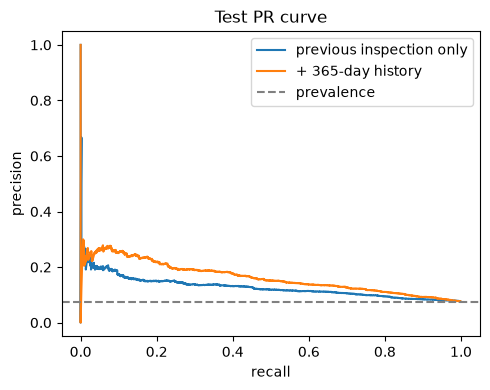

In [11]:
prec_base, rec_base, _ = precision_recall_curve(test["target"], proba_base)
prec_hist, rec_hist, _ = precision_recall_curve(test["target"], proba_hist)

plt.figure(figsize=(5, 4))
plt.plot(rec_base, prec_base, label="previous inspection only")
plt.plot(rec_hist, prec_hist, label="+ 365-day history")
plt.axhline(test["target"].mean(), linestyle="--", color="gray", label="prevalence")
plt.xlabel("recall")
plt.ylabel("precision")
plt.title("Test PR curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_365d_pr_curve.png", dpi=100)
plt.show()

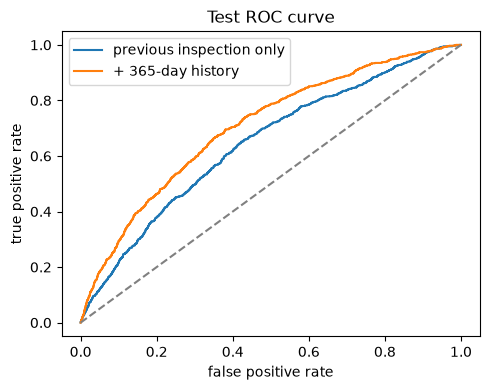

In [12]:
fpr_base, tpr_base, _ = roc_curve(test["target"], proba_base)
fpr_hist, tpr_hist, _ = roc_curve(test["target"], proba_hist)

plt.figure(figsize=(5, 4))
plt.plot(fpr_base, tpr_base, label="previous inspection only")
plt.plot(fpr_hist, tpr_hist, label="+ 365-day history")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.title("Test ROC curve")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/logistic_365d_roc_curve.png", dpi=100)
plt.show()

## Coefficients (history model)

Standardized features, so these compare relative influence, not raw units. Positive means higher predicted Non-Pass log-odds, holding the other features constant, not a causal claim and not a direct percentage change in risk.

In [13]:
coefs = pipe_hist.named_steps["clf"].coef_[0]
coef_df = pd.DataFrame({"feature": HIST_FEATURES, "coefficient": coefs})
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)
coef_df

,feature,coefficient,abs_coefficient
0,prev_non_pass,-0.639106,0.639106
1,prev_total_infractions,0.488710,0.488710
2,prior_365d_total_infractions,0.442136,0.442136
3,prior_365d_n_non_pass,0.245275,0.245275
4,prev_significant,-0.142814,0.142814
5,prev_crucial,-0.129837,0.129837
6,prior_365d_n_inspections,-0.071309,0.071309
7,prev_minor,-0.063409,0.063409
8,n_inspections_seen_so_far,-0.052290,0.052290
9,days_since_previous_inspection,0.040715,0.040715


`prior_365d_n_non_pass` and `prev_total_infractions` come out with the largest coefficients. `prev_non_pass`, `prior_365d_total_infractions` and `prior_365d_n_non_pass` are all measuring related things (how much recent trouble an establishment has had), so their individual coefficients shouldn't be read one at a time as separate effects, they're likely sharing credit for overlapping signal.

## Save results

In [14]:
results = pd.DataFrame([
    {"model": "baseline_strict_split", "feature_set": "previous inspection only (7 features)",
     "val_pr_auc": metrics_base["val_pr_auc"], "val_roc_auc": metrics_base["val_roc_auc"],
     "threshold": metrics_base["threshold"],
     "test_pr_auc": metrics_base["test_pr_auc"], "test_roc_auc": metrics_base["test_roc_auc"],
     "test_precision": metrics_base["test_precision"], "test_recall": metrics_base["test_recall"],
     "test_f1": metrics_base["test_f1"], "test_accuracy": metrics_base["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
results.to_csv("../outputs/baseline_logistic_strict_temporal_results.csv", index=False)

history_results = pd.DataFrame([
    {"model": "logistic_365d_history", "feature_set": "previous inspection + 365-day history (11 features)",
     "val_pr_auc": metrics_hist["val_pr_auc"], "val_roc_auc": metrics_hist["val_roc_auc"],
     "threshold": metrics_hist["threshold"],
     "test_pr_auc": metrics_hist["test_pr_auc"], "test_roc_auc": metrics_hist["test_roc_auc"],
     "test_precision": metrics_hist["test_precision"], "test_recall": metrics_hist["test_recall"],
     "test_f1": metrics_hist["test_f1"], "test_accuracy": metrics_hist["test_accuracy"],
     "train_rows": len(train), "val_rows": len(val), "test_rows": len(test),
     "train_start": train["inspectionDate"].min(), "train_end": train["inspectionDate"].max(),
     "val_start": val["inspectionDate"].min(), "val_end": val["inspectionDate"].max(),
     "test_start": test["inspectionDate"].min(), "test_end": test["inspectionDate"].max()},
])
history_results.to_csv("../outputs/logistic_365d_history_results.csv", index=False)

coef_df.to_csv("../outputs/logistic_365d_history_coefficients.csv", index=False)
print("saved outputs/baseline_logistic_strict_temporal_results.csv")
print("saved outputs/logistic_365d_history_results.csv")
print("saved outputs/logistic_365d_history_coefficients.csv")

saved outputs/baseline_logistic_strict_temporal_results.csv
saved outputs/logistic_365d_history_results.csv
saved outputs/logistic_365d_history_coefficients.csv


## Interpretation

Under the same strict temporal split, adding 365-day history features improved test PR-AUC from about 0.127 to about 0.162 and ROC-AUC from about 0.64 to about 0.70, with recall at the chosen threshold rising from 0.23 to 0.35. This is a real, moderate improvement over the previous-inspection-only baseline, not a large jump, but it suggests the establishment's broader recent history carries some predictive signal beyond just its last inspection.

This is still a fairly weak model in absolute terms (PR-AUC well under 0.5, plenty of false positives), and it predicts the observed DineSafe Non-Pass outcome, not the establishment's true underlying food safety. No causal claim is being made here, longitudinal history is associated with better discrimination, that's as far as this experiment goes.